# Week 5: Practical Transformers with Hugging Face

In Week 3 and 4 we focused on building robust data pipelines using Hugging Face Datasets. In this lab we continue that workflow and move into transformer architecture using direct inspection and controlled experiments.


By the end of this week we should be able to:

- Understand the transformer architecture.
- Explain practical differences between encoder, decoder, and encoder-decoder models.
- Demonstrate those differences with Hugging Face checkpoints.
- Explain what `pipeline()` abstracts by reproducing the core steps manually.



## Introducion


If Week 3 and 4 we saw how we prepare data for models, this week we look at what a transformer model do with that prepared data.


A transformer pipeline still starts with the same engineering discipline:

- clear inputs and labels
- explicit preprocessing
- reproducible splits
- inspectable outputs


What changes is the model family and the representation capacity:

- transformers use attention to combine token context
- different architecture families produce different behavior
- safety and reproducibility matter when loading pretrained checkpoints


### Why this matters for us

In practice, most teams do not train foundation models from scratch. They select a pretrained checkpoint, adapt prompts/data, and inspect outputs. So architecture literacy is mainly about model selection, debugging, and risk management.


## Setup


Let's start by importing the packages we will need today.

#### Core imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import tensorflow as tf

from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM, AutoModelForCausalLM, AutoModelForSeq2SeqLM, pipeline
import os
from dotenv import load_dotenv
load_dotenv()
HF_TOKEN = os.getenv("HUGGINGFACE_API_KEY")

if not HF_TOKEN:
    raise ValueError(
       "HUGGINGFACE_API_KEY not found.\n"
        "→ Copy .env.example to .env\n"
        "→ Add your HuggingFace API key"
    )


#### Reproducibility defaults


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
sns.set_theme(style='whitegrid')


## Transformer mini glossary


Before we go deeper, define the core words we will repeatedly use.


| Term                    | Meaning                                                                                                                       |
| :---------------------- | :---------------------------------------------------------------------------------------------------------------------------- |
| **Token**               | A unit of text processed by the model (often a word or subword piece).                                                        |
| **Token ID**            | The integer index representing a token in the model’s vocabulary.                                                             |
| **Embedding**           | A dense numeric vector that represents the meaning or properties of a token.                                                  |
| **Attention**           | A mechanism that lets each token weigh and combine information from other tokens in the sequence.                             |
| **Logits**              | The raw output scores produced by the model before converting them into probabilities.                                        |
| **Softmax**             | A function that converts logits into probabilities that sum to 1.                                                             |
| **Residual connection** | A skip connection that adds the input of a layer to its output, helping information and gradients flow through deep networks. |
| **Layer normalization** | A normalization technique applied to activations within a layer to stabilise and speed up training.                           |


## The Transformer

In this section we will go through the three different architechures of an Encoder, Decoder and Encoder-Decoder model to get an intutive understanding of them

### Architecture Overviews


| family              | context direction                                                         | core modelling pattern                              | typical tasks                                       |
| :------------------ | :------------------------------------------------------------------------ | :-------------------------------------------------- | :-------------------------------------------------- |
| **encoder**         | bidirectional (tokens attend to both left and right context)              | build contextual representations of the input       | classification, NER, sentence similarity, fill-mask |
| **decoder**         | left-to-right autoregressive (each token attends only to previous tokens) | predict the next token in a sequence                | text generation, completion, dialogue               |
| **encoder–decoder** | encoder is bidirectional; decoder is autoregressive                       | transform an input sequence into an output sequence | translation, summarisation, question answering      |


## Encoder-Decoder

As we have seen in our slides, the original transformer architecture as an encoder-decoder model where

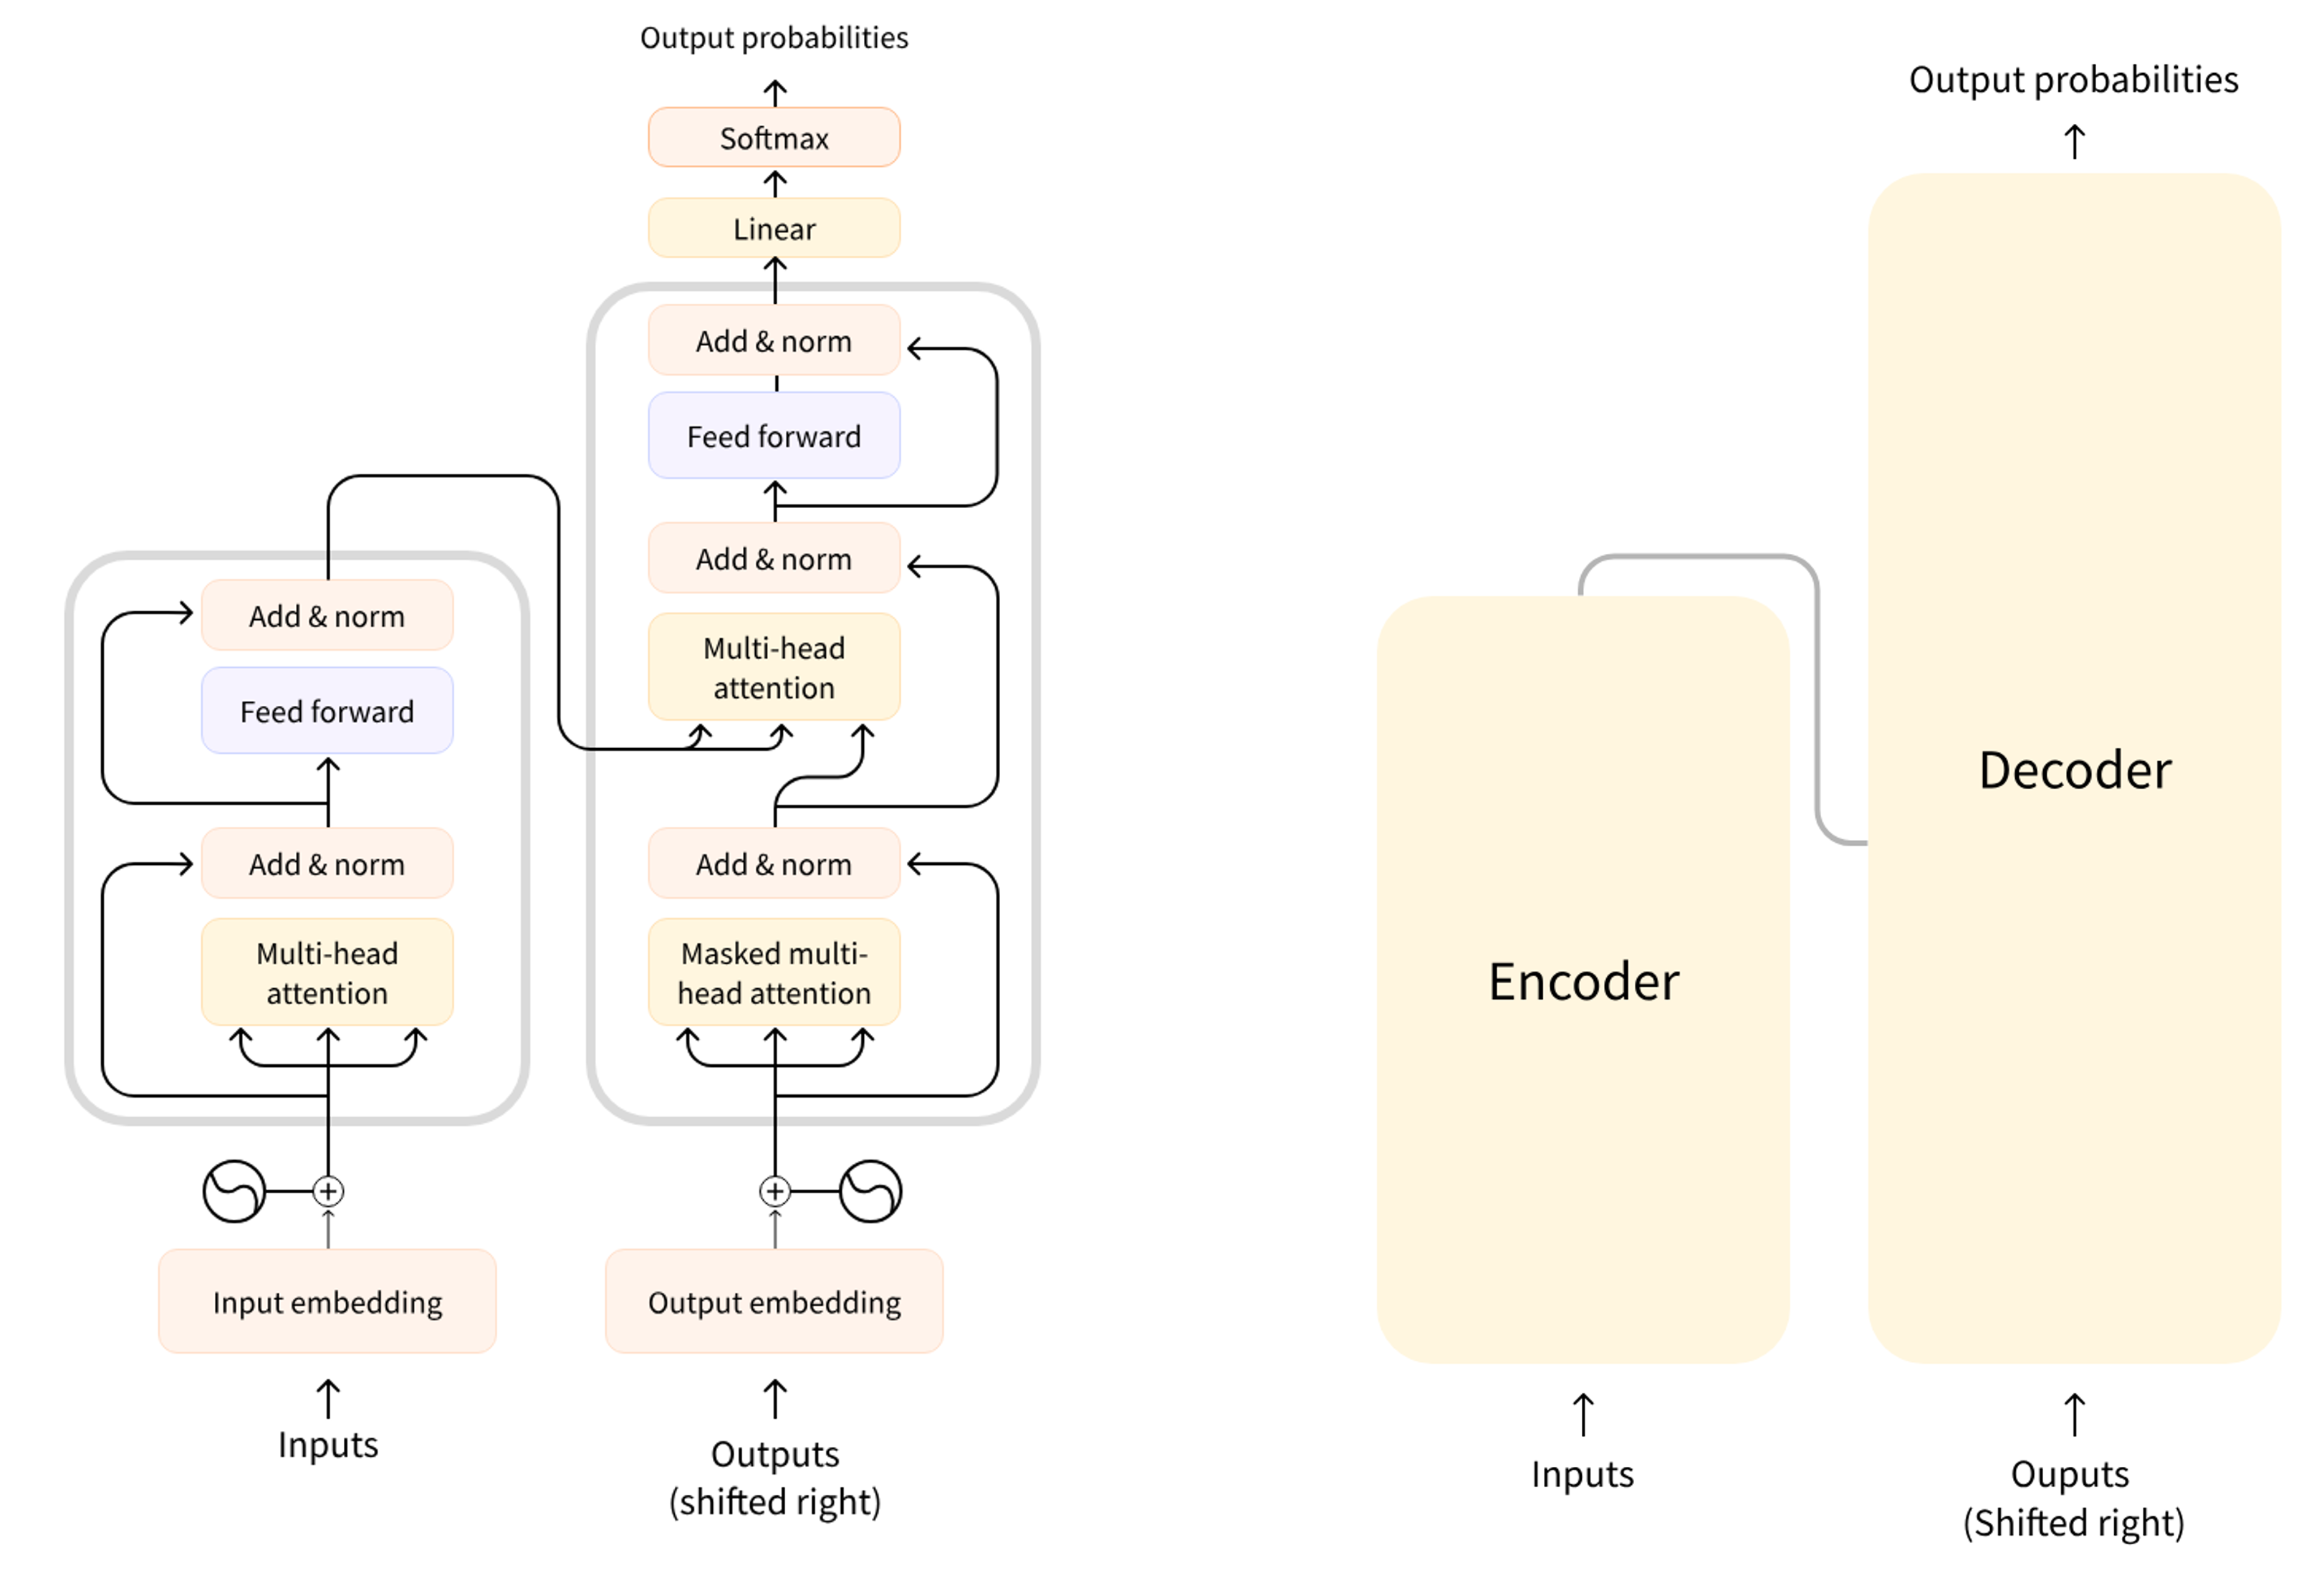

Images above taken from the Hugging Face Learn course on LLMs found here: https://huggingface.co/learn/llm-course/chapter1/4

We will come back to this model in a moment but first we will look at the two parts individually.

## Encoder

An alternative form of a transformer model is to be an Encoder-only model

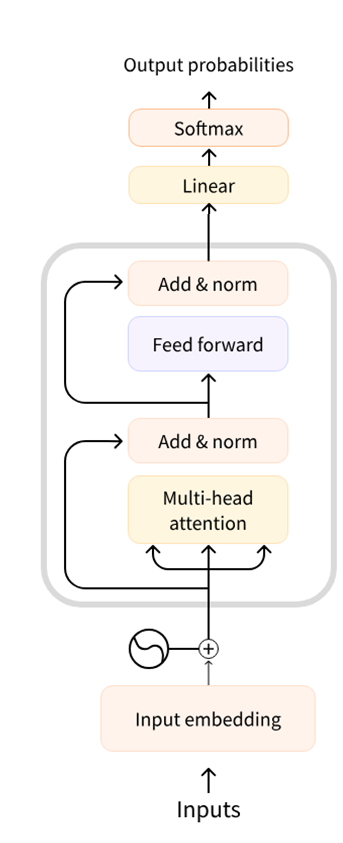

#### Stages of an Encoder

| stage | component             | purpose                                                                                             | input                     | output                                     |
| ----: | :-------------------- | :-------------------------------------------------------------------------------------------------- | :------------------------ | :----------------------------------------- |
|     1 | Tokenizer             | Split text into tokens and convert them into numeric IDs that the model can process                 | raw text                  | `input_ids`, `attention_mask`              |
|     2 | Embedding Layer       | Convert token IDs into dense vectors so the model can represent semantic information numerically    | token IDs                 | token embeddings (dense vectors)           |
|     3 | Positional Encoding   | Add information about token order so the model knows where tokens appear in the sequence            | token embeddings          | position-aware embeddings                  |
|     4 | Self-Attention Blocks | Allow each token to attend to other tokens in the sequence and mix contextual information           | position-aware embeddings | contextual representations                 |
|     5 | Feed-Forward Network  | Apply nonlinear transformations to refine the contextual features learned by attention              | contextual vectors        | transformed contextual vectors             |
|     6 | Task Head             | Map the final representations to task-specific predictions (classification, token prediction, etc.) | final contextual vectors  | logits, probabilities, or generated tokens |


**Note**: Above `attention_mask` tells the transformer which tokens in the input are real tokens and which are padding tokens. It prevents the model from paying attention to padding when computing attention.

### Encoder Benefits

In an encoder model, each token can attend to all other tokens in the input sequence, allowing the model to build a rich, bidirectional understanding of the text. This enables the model to capture relationships between words regardless of their position in the sentence.

Because the model processes the entire input at once, encoder architectures are particularly well suited to tasks that require understanding or analysing text*, such as:

* text classification
* topic detection
* semantic similarity

In these tasks, the goal is not to generate new text but to extract meaning or structure from the input.


### Training an Encoder (Masked Language Modelling) - Pretraining



During training, some tokens in the input are randomly masked, and the model learns to predict the missing tokens using the surrounding context.

Example:

```
Input sentence:
"The cat sat on the mat"

Masked input:
"The cat sat on the [MASK]"
```

The model must predict:

```
[MASK] → mat
```

Because the model can see both the left and right context, this objective works well with the encoder's bidirectional attention.




#### Fine-tuning (task-specific learning)

Once the model is pretrained (so it's learnt generally through masked token prediction) it can then be tuned for specifc tasks such as text classification. This is done by adding a small task head (often something like a feedforward neural network)

Overall the process is:

1. Large Text Corpus (Billions of words)
      
2. Pretraining (Masked Language Modelling)
      
3. Pretrained Encoder Model (e.g. BERT)

4. Add Task Head (Classification / NER / QA)
        
5. Fine-tune on Labelled Dataset

These steps result in a Task-Specific Model.

## Decoder

Another form is to only use the decoder aspect of the architecture

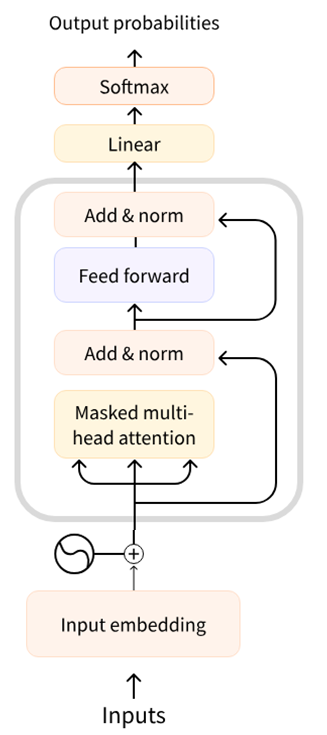

#### Stages of a Decoder

| stage | component                    | purpose                                                                                          | input                     | output                                            |
| ----: | :--------------------------- | :----------------------------------------------------------------------------------------------- | :------------------------ | :------------------------------------------------ |
|     1 | Tokenizer                    | Split text into tokens and convert them into numeric IDs that the model can process              | raw text                  | `input_ids`, `attention_mask`                     |
|     2 | Embedding Layer              | Convert token IDs into dense vectors so the model can represent semantic information numerically | token IDs                 | token embeddings (dense vectors)                  |
|     3 | Positional Encoding          | Add information about token order so the model knows where tokens appear in the sequence         | token embeddings          | position-aware embeddings                         |
|     4 | Masked Self-Attention Blocks | Allow each token to attend only to previous tokens so the model can predict the next token       | position-aware embeddings | autoregressive contextual representations         |
|     5 | Feed-Forward Network         | Apply nonlinear transformations to refine contextual features learned by attention               | contextual vectors        | transformed contextual vectors                    |
|     6 | Language Modeling Head       | Map representations to vocabulary scores to predict the next token in the sequence               | final contextual vectors  | logits over vocabulary → next-token probabilities |


#### Decoder Benefits

In a decoder model, tokens are processed sequentially from left to right, with each token attending only to the tokens that come before it. This autoregressive structure allows the model to generate text one token at a time, continually updating its predictions based on what has already been produced.

Because the model is designed to predict the next token in a sequence, decoder architectures are particularly well suited to tasks that involve text generation, such as:

* text completion
* dialogue and chat systems
* code generation


In these tasks, the goal is not just to understand the input but to produce coherent new text that follows from the previous tokens.


### Training a Decoder Model (Next-token prediction)

Decoder models are trained differently. They predict the next token in a sequence, given the previous tokens. For example,

```
Input:  "The cat sat on the"
Target: "mat"
```


#### Fine-tuning (task-specific learning)



Once the model is pretrained (so it has learnt general language patterns through next-token prediction) it can then be tuned for specific tasks such as dialogue systems, instruction following, or domain-specific text generation.

In decoder models the task head is typically a language modelling head, which maps the model’s hidden representations to probabilities over the vocabulary, This head is usually just a linear projection layer.

During fine-tuning, the model is trained to generate text that matches the desired outputs for the task.

Overall the process is:

1. Large Text Corpus (Billions of words)

2. Pretraining (Next-Token Prediction)

3. Pretrained Decoder Model (e.g. GPT)

4. Language Modelling Head (predict next token)

5. Fine-tune on Task Data
   (e.g. instruction datasets, dialogue datasets, domain text)

These steps result in a Task-Adapted Generative Model.


For example, mretraining might learn general language:

```
"The capital of France is"
→ Paris
```

Fine-tuning might teach the model how to behave for a specific task i.e. like being an instruction model where

```
Input: "Explain gravity in simple terms"
Output: "Gravity is the force that pulls objects toward each other..."
```



## Key differences between Encoder vs Decoder

In an Encoder model:

- Tokens see left and right context
- useful for understanding tasks

In a Decoder model:

- Toke see only previous tokens
- used for generation tasks


## Encoder-Decoder Again

Let's go back to the original transformer: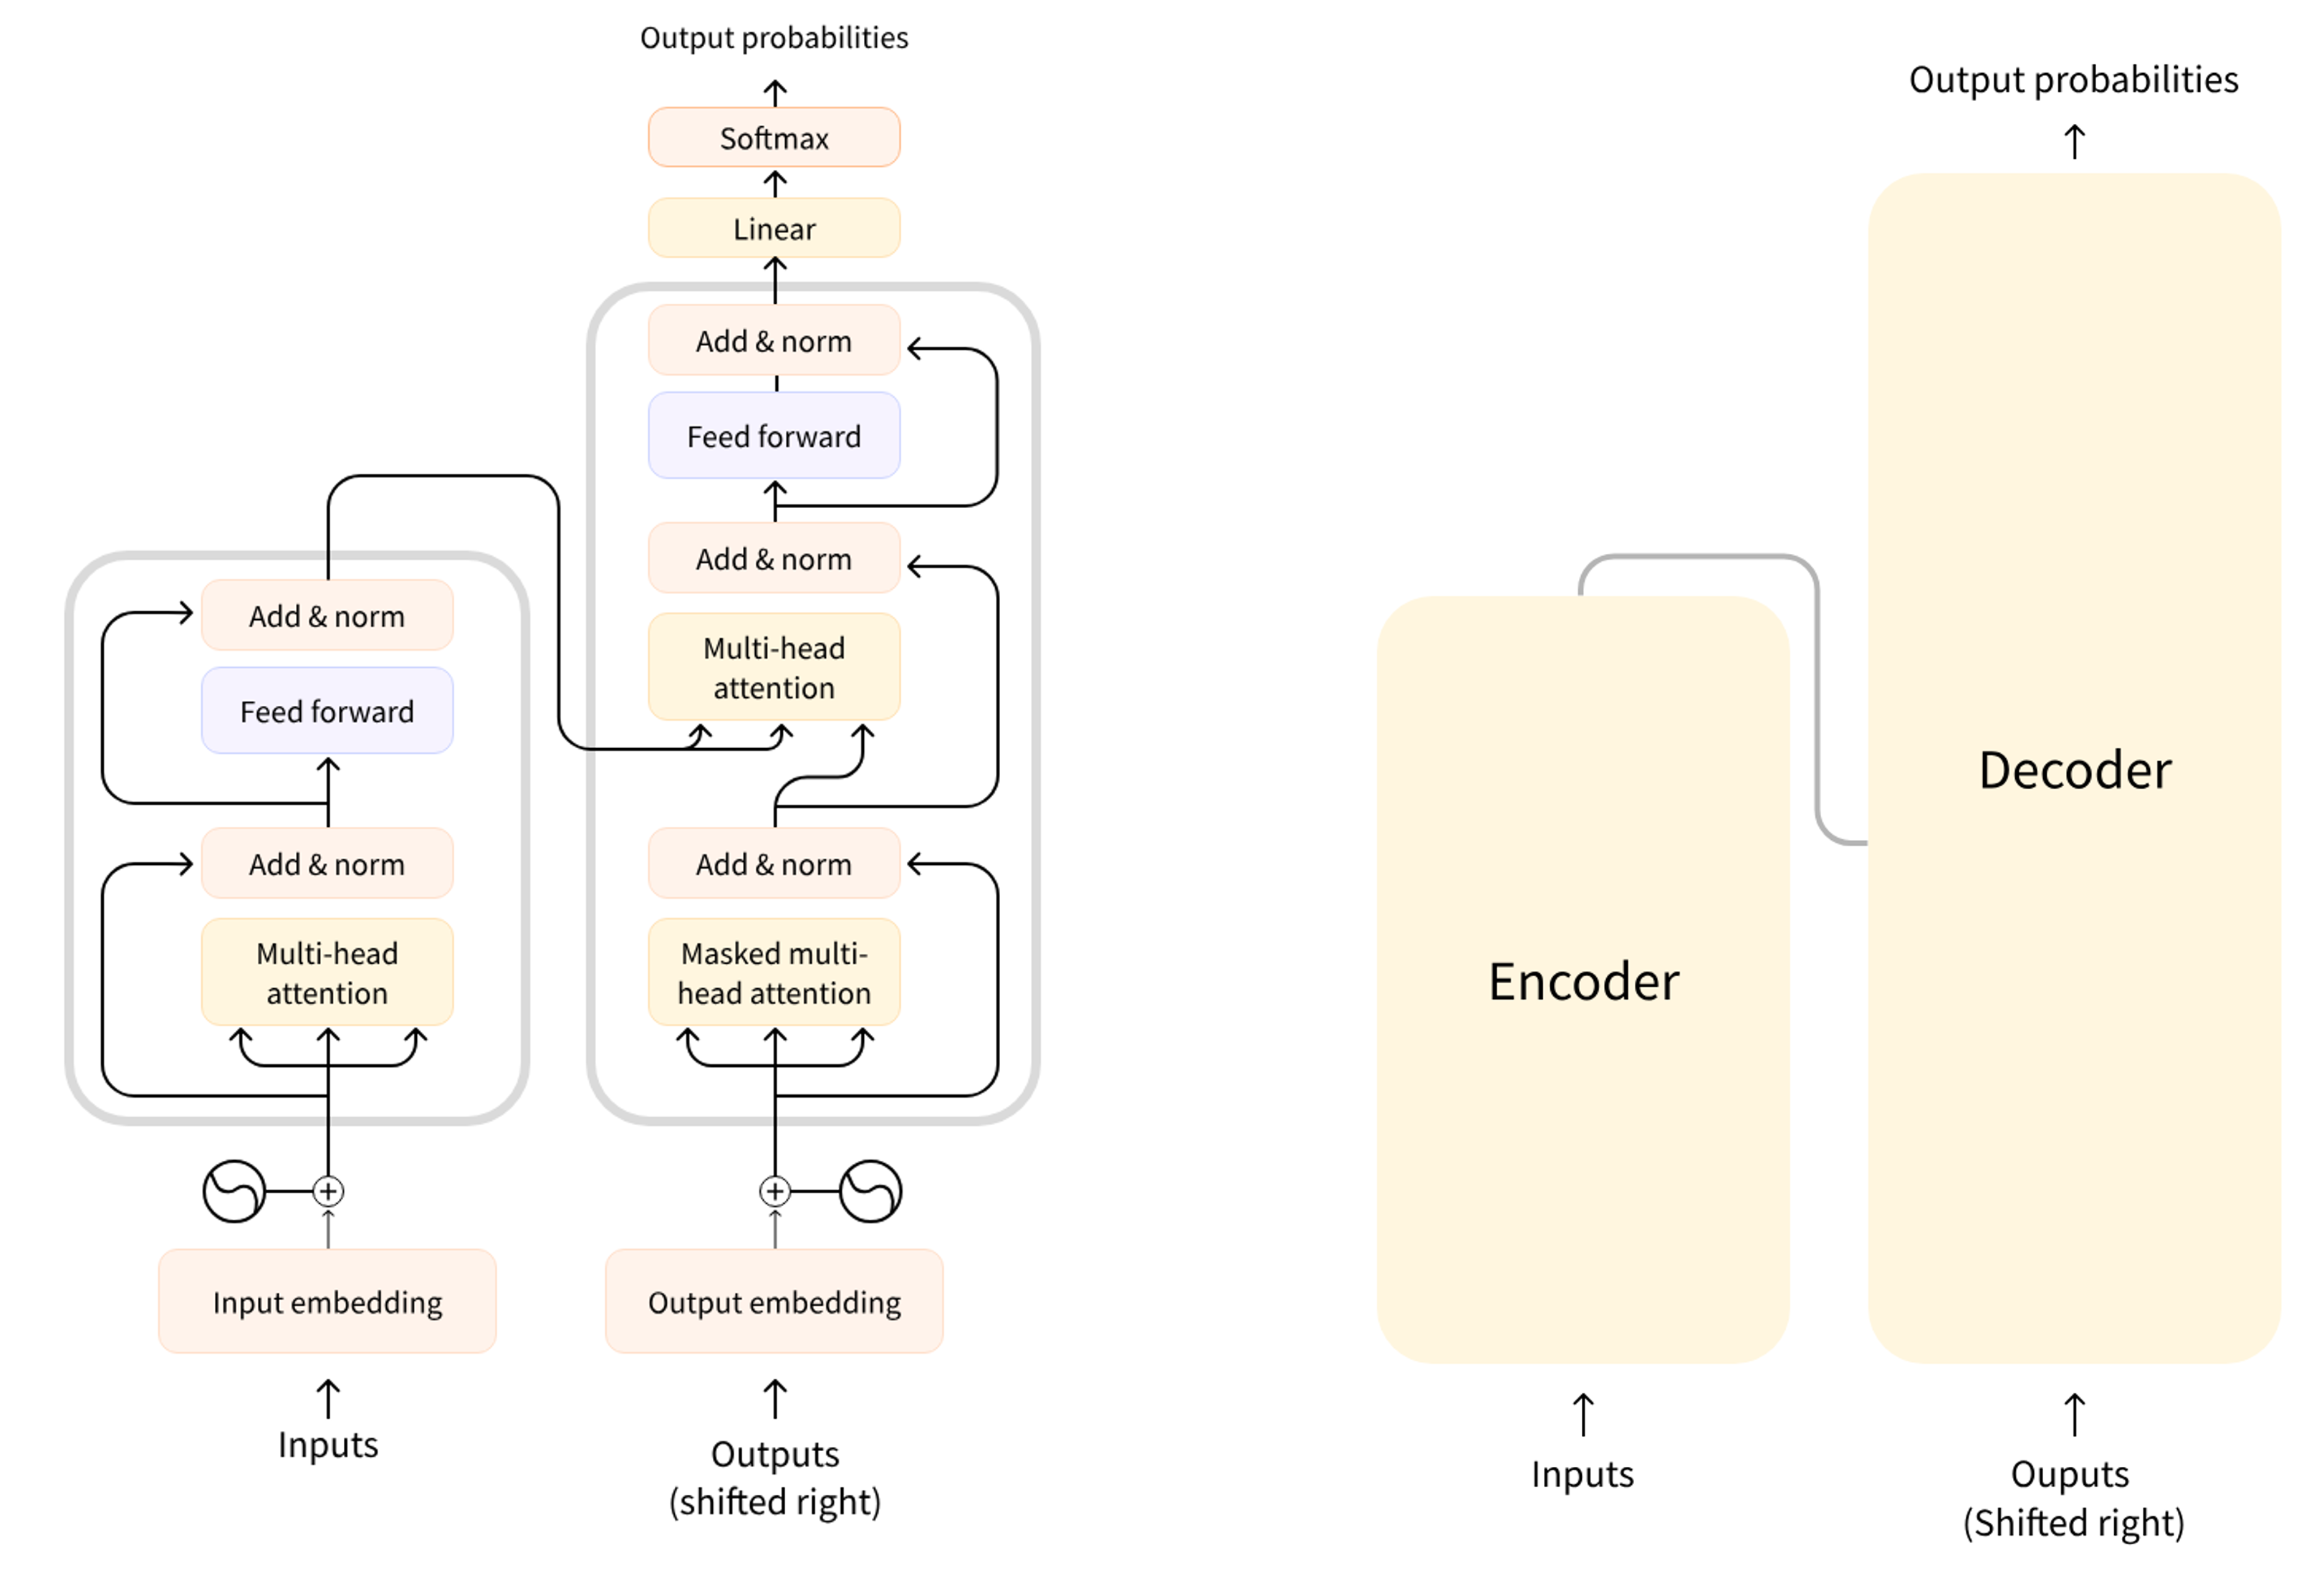

The traditional transformer model effectively combines these stages

| stage | component                           | purpose                                                                                      | input                            | output                                   |
| ----: | :---------------------------------- | :------------------------------------------------------------------------------------------- | :------------------------------- | :--------------------------------------- |
|     1 | Tokenizer                           | Split input and output text into tokens and convert them to numeric IDs                      | raw input text, target text      | encoder `input_ids`, decoder `input_ids` |
|     2 | Embedding Layers                    | Convert token IDs into dense vectors for both encoder and decoder sequences                  | token IDs                        | encoder embeddings, decoder embeddings   |
|     3 | Positional Encoding                 | Add token order information so the model understands sequence structure                      | token embeddings                 | position-aware embeddings                |
|     4 | Encoder Self-Attention Blocks       | Allow input tokens to attend to each other and build contextual representations of the input | encoder embeddings               | encoded input representations            |
|     5 | Masked Decoder Self-Attention       | Allow output tokens to attend only to earlier generated tokens                               | decoder embeddings               | decoder contextual representations       |
|     6 | Cross-Attention (Encoder → Decoder) | Allow decoder tokens to attend to the encoder representations of the input sequence          | decoder states + encoder outputs | context-aware decoder representations    |
|     7 | Feed-Forward Network                | Apply nonlinear transformations to refine contextual features                                | contextual vectors               | transformed contextual vectors           |
|     8 | Language Modeling Head              | Convert decoder representations into vocabulary scores to predict the next token             | final decoder vectors            | logits → next-token probabilities        |


## Quick reference: lab checkpoints

- Encoder demo checkpoint: `google-bert/bert-base-uncased`
- Decoder demo checkpoint: `openai-community/gpt2`
- Encoder-decoder checkpoint: `google-t5/t5-small`


## 4. Safe model loading with `safetensors`


### `safetensors`



As previously discussed, `safetensors` is a safer way of loading a model from Hugging Face Hub. It is a secure and fast file format for storing tensors, designed as a safer alternative to Python's pickle format which is commonly how model weights are stored after training. The problem with the pickle format is it can store arbitrary Python code.

### Steps

When loading a model from the Hugging Face Hub:

1. Check that safetensors files exist.

Look for `model.safetensors` or `model.safetensors.index.json`.

2. Pin the revision.

Save the model's resolved commit SHA so you can load the exact same version again later. The Hub API exposes this as `info.sha`.

3. Load the model with `use_safetensors=True.`
Transformers supports `use_safetensors` in `from_pretrained()`.

4. Keep `trust_remote_code=False`.

Transformers documents that `trust_remote_code=True` can execute code from the Hub on your local machine, so it should only be used for repos you trust.

5. Reuse the saved revision later.

In Transformers, revision defaults to "main", but for reproducibility it is better to save the resolved SHA and use that exact revision in future runs


This keeps classroom behavior reproducible and reduces security risk from unsafe or unexpected loading paths.

### Checking if model has `safetensors`

In [ ]:
from huggingface_hub import HfApi

Let's say we want to check if the encoder model 'bert-base-uncased' has `safetensors`. The `HfApi` allows us to pull in the metadata of models on the Hub.

In [ ]:
HF_API = HfApi()

model_id = 'google-bert/bert-base-uncased'

info = HF_API.model_info(model_id)

The variable `info` now has the information about the model. From this we can pull out the current `main` revision.

In [ ]:
revision = info.sha
revision

Now we have this revision we can save it separately and then use the when using the models. This will mean in the future when using the model we are using the same revision.

In [ ]:
my_revision = "86b5e0934494bd15c9632b12f734a8a67f723594"

A basic check for `safetensors` is using `info.safetensors` which is metadata

In [ ]:
if info.safetensors:
  print('Safetensors exist')
else:
  print('Safetensors do not exist')

A deeper check is to check the actual files exist:

In [ ]:
SAFETENSOR_FILES = (
    "model.safetensors",
    "model.safetensors.index.json",  # sharded models
)

def has_safetensors(api, model_id, revision):
    return any(
        api.file_exists(model_id, filename, revision=revision)
        for filename in SAFETENSOR_FILES
    )

In [ ]:
has_safetensors(HF_API, model_id, my_revision)

So the actual file for `safetensors` does exist.

In summary we could wrap this in a function:

In [ ]:
def get_model_summary(model_id):
    info = HF_API.model_info(model_id)
    revision = info.sha   # exact resolved commit SHA for the current revision

    has_safetensors = any(
        HF_API.file_exists(model_id, filename, revision=revision)
        for filename in SAFETENSOR_FILES
    )

    return {
        "model_id": model_id,
        "revision": revision,
        "has_safetensors": has_safetensors,
    }

For example for the

In [ ]:
encoder = get_model_summary('google-bert/bert-base-uncased')
encoder

### Task

Check the other models listed before to see write down the `sha` of the main revision currently and check for `safetensors`

The models are:

- `google-t5/t5-small`
- `openai-community/gpt2`


#### Solution


In [ ]:
checkpoints = {
    "decoder": "openai-community/gpt2",
    "encoder_decoder": "google-t5/t5-small",
}

In [ ]:
for model_type, model_id in checkpoints.items():
    result = get_model_summary(model_id)
    print(model_type, "->", result)

### Loading Safe Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM


model_id = encoder['model_id']
bert_revision = encoder['revision']


tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    revision=bert_revision,
    trust_remote_code=False,
)

model = AutoModelForMaskedLM.from_pretrained(
    model_id,
    revision=bert_revision,
    trust_remote_code=False,
    use_safetensors=True,
)


Now we can use the model. First we need to tokenise some text:

In [ ]:
text = f"The capital of France is {tokenizer.mask_token}."

inputs = tokenizer(text, return_tensors="pt")
inputs

Now we can push this input through the model

In [ ]:
outputs = model(**inputs)

outputs is the model’s full response to the input.

In [ ]:
mask_pos = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
mask_pos

Here

* `inputs["input_ids"]` is the tensor of token ids for the input sentence.
* `tokenizer.mask_token_id` is the numeric id of the mask token, for BERT usually `[MASK]`.
* `inputs["input_ids"] == tokenizer.mask_token_id` compares every token id to the mask token id, producing a Boolean tensor of `True` and `False`.
* `.nonzero(as_tuple=True)` finds where the `True` values are.
* Because the tensor has shape `[batch_size, sequence_length]`, `nonzero(as_tuple=True)` returns two tensors:
  * the batch indices
  * the position indices within the sequence
* `[1]` takes the sequence positions only.

So `mask_pos` is the position of the mask token in the sentence.


In [ ]:
logits = outputs.logits[0, mask_pos, :]

In [ ]:
logits

Here,

* `outputs.logits` is the model's raw output scores.
* For masked language modelling, its shape is usually:

```python
[batch_size, sequence_length, vocab_size]
```

* `0` means: take the first input in the batch.
* `mask_pos` means: go to the masked token position.
* `:` means: take all vocabulary scores for that position.

So `logits` now contains the model's scores for every possible token that could fill the mask.



In [ ]:
top_ids = torch.topk(logits, 5, dim=1).indices[0].tolist()

Here,

* `torch.topk(logits, 5, dim=1)` finds the 5 highest scores.
* `dim=1` means we are taking the top 5 across the vocabulary dimension.
* The result contains both:

  * the top values
  * the indices where those values occurred
* `.indices` extracts the token ids of those best predictions.
* `[0]` takes the first row, since there is one masked position here.
* `.tolist()` converts the tensor into a normal Python list.

So `top_ids` is a list of the 5 token ids the model thinks are the best replacements for the mask.

In [ ]:
for token_id in top_ids:
    token = tokenizer.decode([token_id]).strip()
    print(text.replace(tokenizer.mask_token, token))

Here,

* `for token_id in top_ids:` loops through each predicted token id.
* `tokenizer.decode([token_id])` converts that token id back into readable text.
* `.strip()` removes extra spaces around the decoded token.
* `text.replace(tokenizer.mask_token, token)` puts that predicted token into the original sentence במקום the mask token.
* `print(...)` shows the completed sentence.

Let's compare this with the `pipeline()`

In [ ]:
from transformers import pipeline

unmasker = pipeline("fill-mask",model=model_id, revision=bert_revision, model_kwargs={"use_safetensors": True})

unmasker(f"The capital of France is {tokenizer.mask_token}.", top_k=5)

### Task

Now I want you to safely build the decoder

Safely load the tokenizer and model.

Requirements:

* use the resolved `revision`
* keep `trust_remote_code=False`
* require `use_safetensors=True` when loading the model
* use `AutoModelForCausalLM.from_pretrained`



#### Solution

In [ ]:
decoder = get_model_summary('openai-community/gpt2')
decoder

In [ ]:
tokenizer_gpt = AutoTokenizer.from_pretrained(
    decoder['model_id'],
    revision=decoder['revision'],
    trust_remote_code=False,
)

model_gpt = AutoModelForCausalLM.from_pretrained(
    decoder['model_id'],
    revision=decoder['revision'],
    trust_remote_code=False,
    use_safetensors=True,
)


### Task

Create a short prompt and tokenize it.

Use:

```python
"Once upon a time in a small seaside town,"
```

Then inspect the token ids.

#### Solution

In [ ]:
prompt = "Once upon a time in a small seaside town,"

inputs = tokenizer_gpt(prompt, return_tensors="pt")
print(inputs["input_ids"])

### Task

Use the model directly to generate text.

Instructions:

* call `model.generate(...)`
* use `max_new_tokens=30`
* set `do_sample=False` for a simple deterministic run
* decode the result back to text

#### Solution

In [ ]:
output_ids = model_gpt.generate(
    **inputs,
    max_new_tokens=30,
    do_sample=False,
)

generated_text = tokenizer_gpt.decode(output_ids[0], skip_special_tokens=True)
print(generated_text)

For decoder models, `generate()` is the standard generation method provided by Transformers.

### Task

Now do the same task using `pipeline`.

Use the same safely loaded `model` and `tokenizer`.

#### Solution

In [ ]:
generator = pipeline("text-generation",model='openai-community/gpt2', revision = decoder['revision'] ,model_kwargs={"use_safetensors": True})

pipeline_output = generator(
    prompt,
    max_new_tokens=30,
    do_sample=False,
)

pipeline_output